In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency
from scipy.stats import shapiro, mannwhitneyu

# Loading GCS files
customers = pd.read_csv("gs://ppnj_data/files/dim_customer.csv")
travel_package = pd.read_csv("gs://ppnj_data/files/dim_travel_package.csv")
sales = pd.read_csv("gs://ppnj_data/files/fact_sales.csv")
travel_guide = pd.read_csv("gs://ppnj_data/files/dim_travel_guide.csv")
feedback = pd.read_csv("gs://ppnj_data/files/dim_feedback.csv")
refund = pd.read_csv("gs://ppnj_data/files/dim_refund.csv")

customers.head()

,customer_id,customer_name,gender,age,email,customer_type
0,MY1000,Zelaya Purwanti,male,34,zelaya.purwanti@outlook.com,new
1,MY1001,"Dr. Mila Melani, M.Farm",female,37,dr.mila.melani.m.farm@hotmail.com,regular
2,MY1002,Cengkal Mulyani,female,23,cengkal.mulyani@yahoo.com,regular
3,MY1003,Siti Susanti,male,27,siti.susanti@yahoo.com,new
4,MY1004,"R.M. Bakiono Hassanah, S.Pd",female,43,r.m.bakiono.hassanah.s.pd@yahoo.com,new


#### 1. Feedback Score vs Refund Request

Objective: To determine if theres significant diference in satisfaction score between customer who requested for refund vs those who didn't

*   Ho: No difference in average feedback scores between refund vs non-refund customers
*   H1: Theres a significant difference feedback scores





In [ ]:
# data preparation

#refund.head()
refund['requested_refund'] = True   # to annotate column where fund has beedn proceed

feedback_refund = feedback.merge(refund[['booking_id','requested_refund']], on='booking_id', how='left')
feedback_refund['requested_refund'] = feedback_refund['requested_refund'].fillna(False)
#feedback_refund.head()

# get satisfaction scores
refund_scores = feedback_refund[feedback_refund['requested_refund']]['satisfaction_score']
no_refund_scores = feedback_refund[~feedback_refund['requested_refund']]['satisfaction_score']

# t-test
t_stat, p_val = ttest_ind(refund_scores, no_refund_scores, equal_var=False)
print(f"T-statistic: {t_stat:.3f}, P-value: {p_val:.4f}")



T-statistic: 0.986, P-value: 0.3386


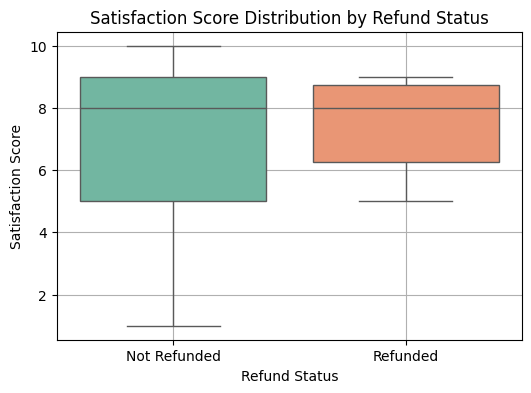

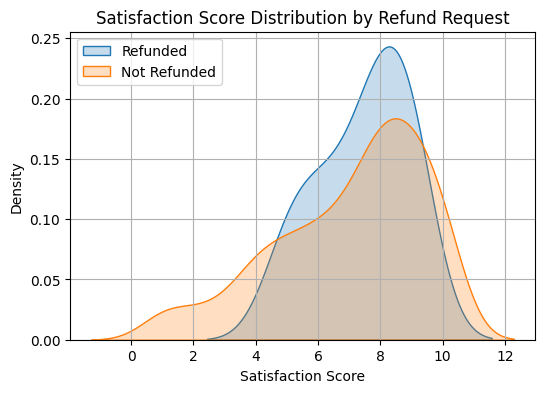

In [ ]:
# Visualize Distributions

feedback_refund['refund_status'] = feedback_refund['requested_refund'].map({True:'Refunded', False:'Not Refunded'})

# boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(data=feedback_refund , x='refund_status', y='satisfaction_score', palette='Set2')
plt.title('Satisfaction Score Distribution by Refund Status')
plt.xlabel('Refund Status')
plt.ylabel('Satisfaction Score')
plt.grid(True)
plt.show()

# kde plot
plt.figure(figsize=(6,4))
sns.kdeplot(refund_scores, label='Refunded', shade=True)
sns.kdeplot(no_refund_scores, label='Not Refunded', shade=True)
plt.title('Satisfaction Score Distribution by Refund Request')
plt.xlabel('Satisfaction Score')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Normlaity Checks use Shapiro and Mannwhitneyu

shapiro_refund = shapiro(refund_scores)
shapiro_no_refund = shapiro(no_refund_scores)
print("Shapiro-Wilk Test (Refunded):", shapiro_refund)
print("Shapiro-Wilk Test (Not Refunded):", shapiro_no_refund)

stat, p = mannwhitneyu(refund_scores, no_refund_scores, alternative='two-sided')
print(f'Mann-Whitney U statistic = {stat:.4f}, p-value = {p:.4g}')


Shapiro-Wilk Test (Refunded): ShapiroResult(statistic=np.float64(0.8763830335203862), pvalue=np.float64(0.05162931928281731))
Shapiro-Wilk Test (Not Refunded): ShapiroResult(statistic=np.float64(0.9130226953052021), pvalue=np.float64(2.588473381120319e-12))
Mann-Whitney U statistic = 2215.0000, p-value = 0.8286


#### Results:

**T_test**:

*   p = 0.3386 > 0.05,fail to reject Ho.
*   There is no statistically difference  in satisfaction scores between customers who requested refund and thos who did not

Bases on this test, refund requests do not appear to have a significant effect on satsifaction scores.

**Sahpiro Wilk-Test**:
- checking for data normality

*   Refunded
- Shapiro-Wilk Test (Refunded): ShapiroResult(statistic=np.float64(0.8763830335203862), pvalue=np.float64(0.05162931928281731))
- p > 0.05, we fail to reject the null hypothesis — the data is likely normally distributed.
*   Non-Refunded
-Shapiro-Wilk Test (Not Refunded): ShapiroResult(statistic=np.float64(0.9130226953052021), pvalue=np.float64(2.588473381120319e-12))
- p < 0.05, we reject the null hypothesis — the data is not normally distributed.

* proceed with **Mann-Whitney U** test:
- Mann-Whitney U statistic = 2215.0000, p-value = 0.8286
- p >= 0.05: No significant difference


#### 2. Discount Promotion vs Satisfaction Score

Objective: Does giving a discount improve customer satisfaction?
         : Improve the approach steps of steps
         - visualize
         - normality checks
         - hypothesis test

*   Ho: The average satisfaction score is the same whether a discount is applied or not.
*   H1: Satisfaction scores differ depending on whether a discount is applied.





<Axes: xlabel='satisfaction_score', ylabel='Density'>

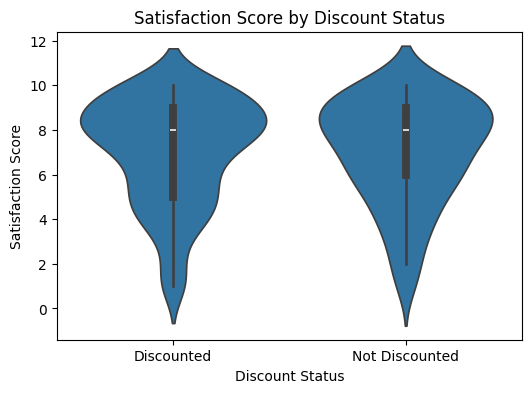

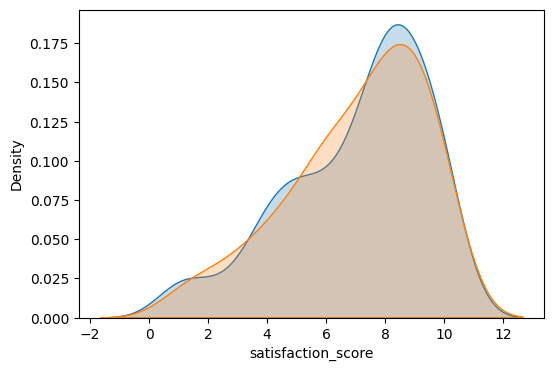

In [ ]:
# Visualize distributions

#violinplot
feedback_sales['discount_status'] = feedback_sales['discounted'].map({True:'Discounted', False:'Not Discounted'})
plt.figure(figsize=(6,4))
sns.violinplot(data=feedback_sales, x='discount_status', y='satisfaction_score')
plt.title('Satisfaction Score by Discount Status')
plt.xlabel('Discount Status')
plt.ylabel('Satisfaction Score')

# kdeplot
plt.figure(figsize=(6,4))
sns.kdeplot(discounted_scores, label='Discounted', shade=True)
sns.kdeplot(non_discounted_scores, label='Not Discounted', shade=True)

In [ ]:
### Normality Checks

'''
- Based on the visualizations (KDE and violin plots), both distributions appear to be **left-skewed**, particularly for the discounted group.
- This suggests that the data may not be normally distributed.
- However, visual inspection is subjective. To confirm this assumption, we perform the **Shapiro-Wilk test** for normality on both groups.
'''

# Shapiro-Wilk tests
print("Shapiro-Wilk (Discounted):", shapiro(discounted_scores))
print("Shapiro-Wilk (Not Discounted):", shapiro(non_discounted_scores))

Shapiro-Wilk (Discounted): ShapiroResult(statistic=np.float64(0.9083223587253086), pvalue=np.float64(1.3553450336934056e-09))
Shapiro-Wilk (Not Discounted): ShapiroResult(statistic=np.float64(0.9193366359259708), pvalue=np.float64(1.3270511674836503e-06))


In [ ]:
# data preparation

#print(feedback.columns)
#print(sales.columns)

feedback_sales = feedback.merge(sales[['booking_id', 'discount_promotion']], on='booking_id')
feedback_sales['discounted'] = feedback_sales['discount_promotion'] > 0
#feedback_sales.head()

discounted_scores = feedback_sales[feedback_sales['discounted']]['satisfaction_score']
non_discounted_scores = feedback_sales[~feedback_sales['discounted']]['satisfaction_score']

#print(discounted_scores.head())
#print(non_discounted_scores.head())

# Mann-Whitney U test
u_stat, p_val = mannwhitneyu(discounted_scores, non_discounted_scores, alternative='two-sided')
print(f"Mann-Whitney U statistic = {u_stat:.4f}, p-value = {p_val:.4f}")


alpha = 0.05
if p_val < alpha:
    print("Result: Significant difference in satisfaction scores between discounted and non-discounted customers.")
else:
    print("Result: No significant difference in satisfaction scores based on discount status.")


Mann-Whitney U statistic = 12367.5000, p-value = 0.8561
Result: No significant difference in satisfaction scores based on discount status.


#### Results:

**Sahpiro Wilk-Test**:
- checking for data normality

*   Discounted
- Shapiro-Wilk (Discounted): ShapiroResult(statistic=np.float64(0.9083223587253086), pvalue=np.float64(1.3553450336934056e-09))
- p < 0.05, we reject the null hypothesis — the data is likely not normally distributed.
*   Non-Refunded
- Shapiro-Wilk (Not Discounted): ShapiroResult(statistic=np.float64(0.9193366359259708), pvalue=np.float64(1.3270511674836503e-06))
- p < 0.05, we reject the null hypothesis — the data is not normally distributed.

**Mann-whiteny u test**:

*   p = 0.8561 > 0.05,fail to reject Ho.
*   The average satisfaction score is the same whether a discount is applied or not.

There is no statistically significant difference in satisfaction scores between customers who received a discount and those who didn’t.
